# Conventional CNN with ROI Extraction

In [1]:
# Standard library imports
import os
import json
import math

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
import cv2
import matplotlib.image as mpimg  # For loading images

# Machine learning libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

c:\Users\david\miniconda3\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
def create_dummy_image():
    dummy_image_path = "../dataset/nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255

In [3]:
# Define the directory containing the labeled dataset
directory = r'C:\Users\david\Desktop\project\dataset\Labeled'

# Initialize an empty list to store data
data = []

# Iterate through all files in the directory
for file in os.listdir(directory):
    if file.lower().endswith('.jpg'):
        image_path = os.path.join(directory, file)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

df = pd.DataFrame(data)
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB
None


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


In [4]:
def extract_roi(image_path, json_path):
    """
    Extracts a region of interest (ROI) that includes the entire component and both solder joints.
    Ensures the component is centered and fully visible with adequate padding.
    """
    try:
        # Read the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        with open(json_path, 'r') as f:
            content = json.load(f)
            shapes = content.get('shapes', [])
            
            if shapes and isinstance(shapes, list):
                # Get all points from all shapes
                all_points = []
                for shape in shapes:
                    points = shape.get('points', [])
                    if points:
                        all_points.extend(points)
                
                if all_points:
                    # Convert points to numpy array
                    points = np.array(all_points, dtype=np.int32)
                    
                    # Get bounding box
                    x, y, w, h = cv2.boundingRect(points)
                    
                    # Calculate center
                    center_x = x + w // 2
                    center_y = y + h // 2
                    
                    # Make ROI wider to ensure both solder joints are visible
                    # Width is 3x the component width or height (whichever is larger)
                    size_w = max(w, h) * 3
                    # Height is 2x the component height
                    size_h = h * 2
                    
                    # Calculate crop coordinates with padding
                    x1 = max(0, center_x - size_w // 2)
                    y1 = max(0, center_y - size_h // 2)
                    x2 = min(image.shape[1], x1 + size_w)
                    y2 = min(image.shape[0], y1 + size_h)
                    
                    # Adjust coordinates if they hit image boundaries
                    if x1 == 0:
                        x2 = min(image.shape[1], size_w)
                    if y1 == 0:
                        y2 = min(image.shape[0], size_h)
                    if x2 == image.shape[1]:
                        x1 = max(0, x2 - size_w)
                    if y2 == image.shape[0]:
                        y1 = max(0, y2 - size_h)
                    
                    # Extract ROI
                    roi = image[y1:y2, x1:x2]
                    return roi
                    
            print(f"No valid shapes found in {json_path}")
            return image
            
    except Exception as e:
        print(f"Error extracting ROI from {image_path}: {e}")
        return image

In [5]:
# Preprocessing
df_filtered = df[~df['label'].isin(['good', 'no_good'])].copy()
target_size = (224, 224)
batch_size = 32

train_df, val_df = train_test_split(
    df_filtered, test_size=0.2, stratify=df_filtered['label'], random_state=42
)

# Define class indices manually
class_indices = {label: idx for idx, label in enumerate(train_df['label'].unique())}

# Define Albumentations augmentation pipeline
augmentation_pipeline = A.Compose([
    A.Resize(target_size[0], target_size[1]),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Validation pipeline without augmentations
val_pipeline = A.Compose([
    A.Resize(target_size[0], target_size[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Custom data generator using Albumentations
def albumentations_data_generator(df, batch_size, augmentations, target_size, is_training=True):
    while True:
        for i in range(0, len(df), batch_size):
            batch_df = df.iloc[i:i+batch_size]
            images = []
            labels = []
            for _, row in batch_df.iterrows():
                # Extract ROI
                image_path = row['filename']
                json_path = image_path.replace('.jpg', '.json')
                roi = extract_roi(image_path, json_path)
                
                # Apply augmentations
                augmented = augmentations(image=roi)
                image = augmented['image']
                
                # Ensure image is a numpy array and has the correct shape
                image = np.array(image)
                if len(image.shape) == 2:  # Grayscale image
                    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
                elif image.shape[0] == 3:  # Channels-first format
                    image = np.transpose(image, (1, 2, 0))
                
                images.append(image)
                label = class_indices[row['label']]
                labels.append(tf.keras.utils.to_categorical(label, num_classes=len(class_indices)))
            
            yield np.array(images), np.array(labels)

# Create generators with appropriate augmentation pipelines
train_generator = albumentations_data_generator(train_df, batch_size, augmentation_pipeline, target_size, is_training=True)
val_generator = albumentations_data_generator(val_df, batch_size, val_pipeline, target_size, is_training=False)

# CNN

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(target_size[0], target_size[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Add dropout for regularization
    layers.Dense(len(class_indices), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Calculate steps per epoch
steps_per_epoch = math.ceil(len(train_df) / batch_size)
validation_steps = math.ceil(len(val_df) / batch_size)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,  # Specify steps per epoch
    epochs=20,  # Increase the number of epochs
    validation_data=val_generator,
    validation_steps=validation_steps  # Specify validation steps
)

# Save the trained model
model.save("../model/conventional_cnn_roi.h5")

c:\Users\david\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,779 (91.20 MB)

 Trainable params: 23,907,779 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4477 - loss: 25.2603 - val_accuracy: 0.2000 - val_loss: 8.3841
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4477 - loss: 25.2603 - val_accuracy: 0.2000 - val_loss: 8.3841
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 962ms/step - accuracy: 0.2773 - loss: 10.7537 - val_accuracy: 0.5333 - val_loss: 1.0991
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 962ms/step - accuracy: 0.2773 - loss: 10.7537 - val_accuracy: 0.5333 - val_loss: 1.0991
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4600 - loss: 1.2943 - val_accuracy: 0.5333 - val_loss: 1.0331
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4600 - loss: 1.2943 - val_accuracy: 0.5333 - val_loss: 1.0331
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5569 - loss: 0.9855 - val_accuracy: 0.5333 - val_loss: 1.0426
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5569 - loss: 0.9855 - val_accuracy: 0.5333 - val_loss: 1.0426
Epoch 

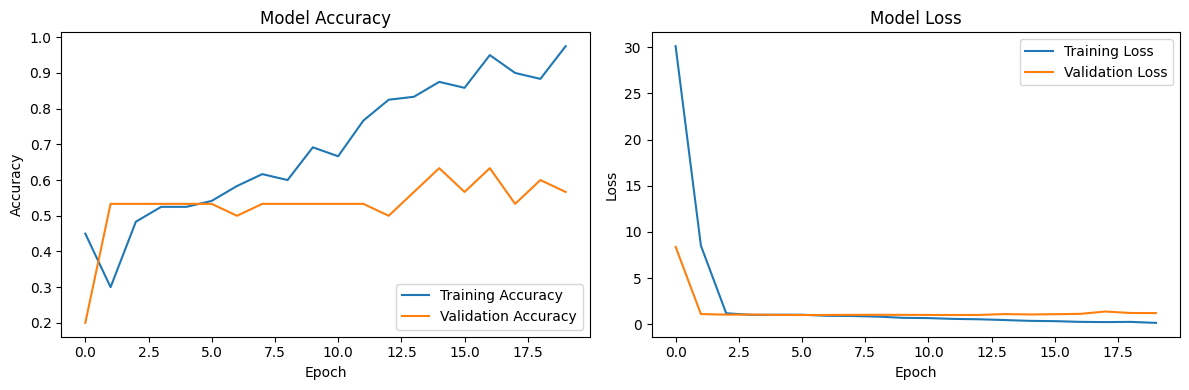

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Show the plots
plt.tight_layout()
plt.show()

# Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Classification Report:
               precision    recall  f1-score   support

  exc_solder       0.65      0.81      0.72        16
       spike       0.44      0.50      0.47         8
 poor_solder       0.00      0.00      0.00         6

    accuracy                           0.57        30
   macro avg       0.36      0.44      0.40        30
weighted avg       0.47      0.57      0.51        30

Classification Report:
               precision    recall  f1-score   support

  exc_solder       0.65      0.81      0.72        16
       spike       0.44      0.50      0.47         8
 poor_solder       0.00      0.00      0.00         6

    accuracy                           0.57        30
   macro avg       0.36      0.44      0.40        30
weighted avg       0.47      0.57      0.51        30



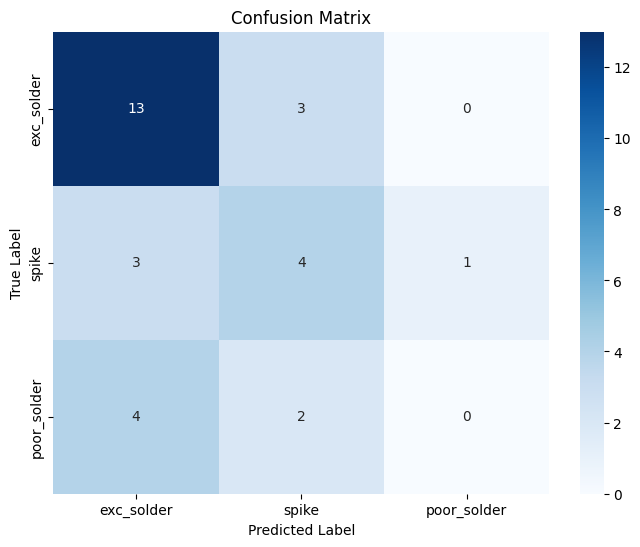

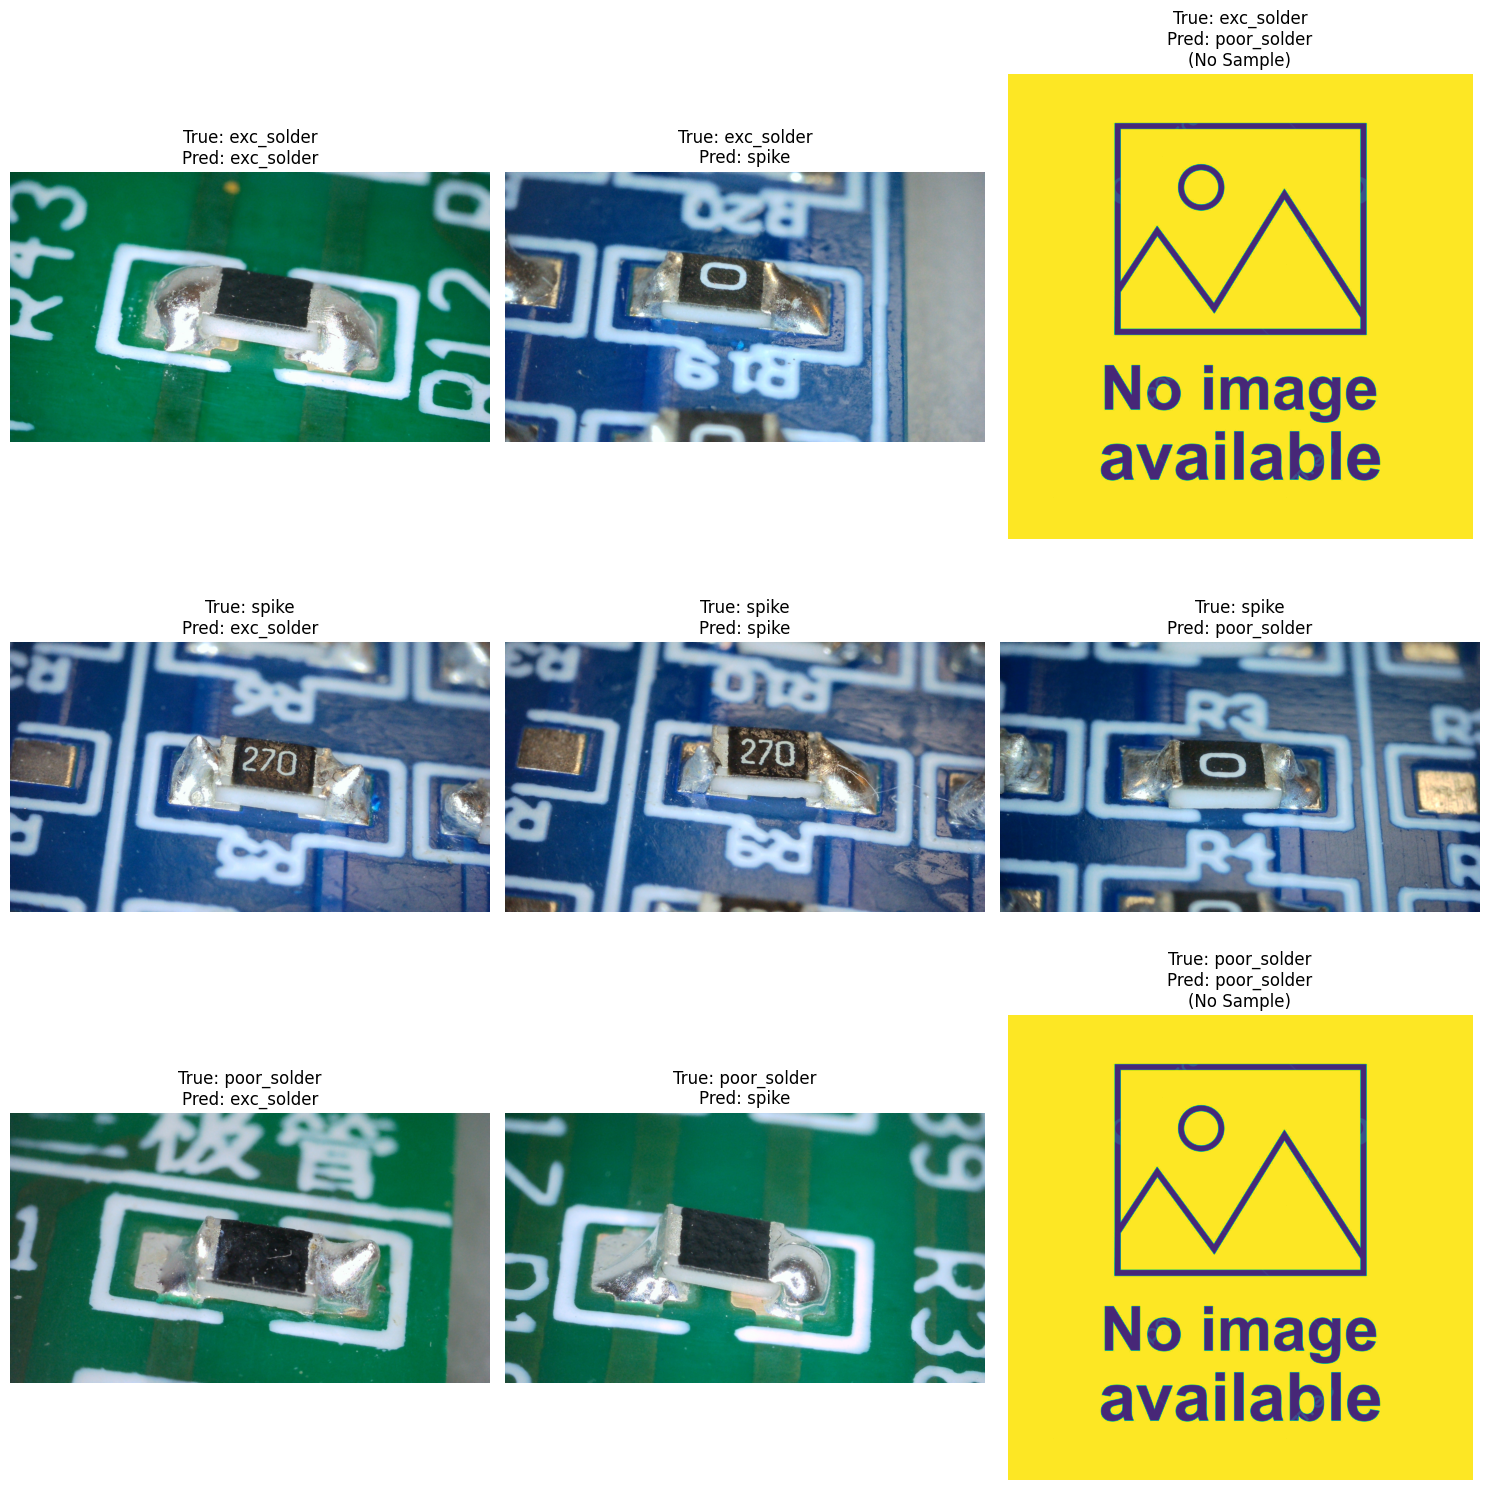

In [8]:
# Predict
val_steps = math.ceil(len(val_df) / batch_size)  # Calculate validation steps
predictions = model.predict(val_generator, steps=val_steps)
predicted_classes = np.argmax(predictions, axis=1)

# Ground truth labels
true_classes = val_df['label'].map(class_indices).values  # Map string labels to integers
class_labels = list(class_indices.keys())

# Classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:\n", report)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Error analysis: Sample one image from each confusion matrix cell
plt.figure(figsize=(15, 15))
num_classes = len(class_labels)

# Track the number of subplots dynamically
subplot_count = 0

for true_label in range(num_classes):
    for predicted_label in range(num_classes):
        # Find indices of samples for the current true and predicted label pair
        indices = np.where((true_classes == true_label) & (predicted_classes == predicted_label))[0]
        
        if len(indices) > 0:
            # Sample one image from the indices
            idx = indices[0]  # Take the first one (or random.choice(indices) for randomness)
            image_path = val_df['filename'].iloc[idx]

            # Load the image
            if os.path.exists(image_path):
                image = plt.imread(image_path)
            else:
                image = create_dummy_image()
        else:
            # Use a placeholder image if no sample exists for this cell
            image = create_dummy_image()
        
        # Display the image
        subplot_count += 1
        plt.subplot(num_classes, num_classes, subplot_count)
        plt.imshow(image)
        title = f"True: {class_labels[true_label]}\nPred: {class_labels[predicted_label]}"
        if len(indices) == 0:
            title += "\n(No Sample)"
        plt.title(title)
        plt.axis('off')

# Adjust layout and display the plot
if subplot_count > 0:
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications to display.")